# Baseline: hierarkisk multi-head modell (nivå 1 + nivå 2)

Denne notebooken trener og evaluerer en hierarkisk baseline for multiattributt kjøretøygjenkjenning basert på en **pretrent dyp læringsmodell** (f.eks. en pretrent CNN-backbone). Oppsettet bruker ferdige `train/val/test`-splitter, bygger et todelt labelhierarki og trener én delt, pretrent backbone med to output-hoder:

- **Nivå 1 (`lvl1`)**: `Tesla` vs `Other`
- **Nivå 2 (`lvl2`)**: Tesla-underklasser, kun aktiv for bilder som faktisk tilhører `Tesla`

Notebooken dekker hele løpet fra innlesing av datasplitt og preprocessing til finjustering av den pretrente modellen, valg av beste epoch på valideringssettet og lysstratifisert evaluering på nivå 1 og nivå 2.

### Imports og maskinvareoppsett

Importerer bibliotekene som brukes videre i notebooken og gjør et enkelt GPU-oppsett for TensorFlow. XLA slås av, og dersom en GPU er tilgjengelig settes `memory_growth` for å redusere risikoen for at TensorFlow reserverer all videominne ved oppstart.

In [1]:
# 0) Imports
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
tf.config.optimizer.set_jit(True)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

2026-03-29 11:42:40.262180: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-29 11:42:40.272069: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774777360.283482   72305 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774777360.287110   72305 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-29 11:42:40.299455: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

TF: 2.18.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Prosjektstruktur, konstanter og datasplitt-stier

Definerer sentrale konstanter for eksperimentet, blant annet seed, inputstørrelse og batch-størrelse. Deretter lokaliseres prosjektroten automatisk ved å lete etter `datasplitt/train.csv`, og de faste filstiene til `train`, `val` og `test` settes opp.


In [ ]:
# 1) Les inn datasplitt og vis info
from pathlib import Path
import numpy as np
import tensorflow as tf

# Konstanter og prosjektstruktur
SEED = 42
IMG_SIZE = (300, 300)     # Modellens inputstørrelse
SHORT_SIDE = 300          # Resize korteste side til 300 før crop
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

tf.random.set_seed(SEED)
np.random.seed(SEED)

def find_project_root(start: Path) -> Path:
    # Look upwards from current working dir until we find the split CSVs
    for p in [start, *start.parents]:
        if (p / "datasplitt" / "train.csv").exists():
            return p

    # Fallback: common locations (just in case)
    candidates = [
        Path.home() / "studier" / "DAT191" / "visual-vehicle-recognition-varying-lighting-conditions",
        Path.home() / "DAT191" / "visual-vehicle-recognition-varying-lighting-conditions",
    ]
    for p in candidates:
        if (p / "datasplitt" / "train.csv").exists():
            return p

    raise FileNotFoundError(
        "Fant ikke prosjektrot: forventet datasplitt/train.csv. "
        "Sjekk at datasplitt/ finnes og at du står i riktig repo."
    )

CWD = Path.cwd()
PROJECT_ROOT = find_project_root(CWD)

SPLIT_DIR = PROJECT_ROOT / "datasplitt_preprocessed"
TRAIN_CSV = SPLIT_DIR / "train_processed.csv"
VAL_CSV   = SPLIT_DIR / "val_processed.csv"
TEST_CSV  = SPLIT_DIR / "test_processed.csv"

print("CWD:", CWD)
print("Project root:", PROJECT_ROOT)
print("Train CSV:", TRAIN_CSV, "exists:", TRAIN_CSV.exists())
print("Val CSV:", VAL_CSV, "exists:", VAL_CSV.exists())
print("Test CSV:", TEST_CSV, "exists:", TEST_CSV.exists())



CWD: /media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/notebooks/pretrained
Project root: /media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions
Train CSV: /media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt_preprocessed/train_processed.csv exists: True
Val CSV: /media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt_preprocessed/val_processed.csv exists: True
Test CSV: /media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt_preprocessed/test_processed.csv exists: True


### Les inn datasplittene og kontroller grunnstrukturen

Setter `IMG_ROOT` til roten for bildematerialet, leser inn `train_df`, `val_df` og `test_df`, og viser et lite utsnitt av treningsdataene. Dette gir en tidlig kontroll av at datasplittene finnes, kan leses og inneholder forventede kolonner.

In [3]:
# 2) Last split CSV-er

# Viktig: `IMG_ROOT / <image>` må peke til en faktisk fil på disk.
# Eksempelstier i CSV kan være som: Eksternt/Tesla/... eller Egenprodusert/...
# 2) Sett IMG_ROOT (datasett-roten som 'image' er relativ til)
IMG_ROOT = PROJECT_ROOT / "datasett_preprocessed"
print("IMG_ROOT:", IMG_ROOT)
print("IMG_ROOT exists:", IMG_ROOT.exists())

if not IMG_ROOT.exists():
    raise FileNotFoundError(f"Finner ikke IMG_ROOT: {IMG_ROOT}")

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)
train_df['image'] = "train/" + train_df['image'].astype(str)
val_df['image']   = "val/"   + val_df['image'].astype(str)
test_df['image']  = "test/"  + test_df['image'].astype(str)

display(train_df.head())
print("train/val/test:", len(train_df), len(val_df), len(test_df))
print("columns:", train_df.columns.tolist())

IMG_ROOT: /media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_preprocessed
IMG_ROOT exists: True


,color,image,lighting,model,source,year,lvl1,lvl2,strat_key,w_lvl2,y_lvl1,w_lvl1,y_lvl2,processed_image
0,White,train/Egenprodusert/non-tesla/dark/IMG_1954.jpg,Dark,Other car,internal,NaN,Other,NaN,Other|NA|Dark,0.0,0,1.0,0,train/Egenprodusert/non-tesla/dark/IMG_1954.jpg
1,Black/Dark gray,train/Egenprodusert/Tesla/daylight/IMG_1802.jpg,Light,3 2017–2023,internal,2017–2023,Tesla,3 2017–2023,Tesla|3 2017–2023|Light,1.0,1,1.0,0,train/Egenprodusert/Tesla/daylight/IMG_1802.jpg
2,Light gray/Silver,train/Egenprodusert/Tesla/dark/IMG_3834.jpg,Dark,X,internal,2016–2020,Tesla,X,Tesla|X|Dark,1.0,1,1.0,4,train/Egenprodusert/Tesla/dark/IMG_3834.jpg
3,Red,train/Egenprodusert/non-tesla/low-light/IMG_45...,Medium,Other car,internal,NaN,Other,NaN,Other|NA|Medium,0.0,0,1.0,0,train/Egenprodusert/non-tesla/low-light/IMG_45...
4,Red,train/Eksternt/non-tesla/daylight/0476_03052.jpg,Light,Other car,external,NaN,Other,NaN,Other|NA|Light,0.0,0,1.0,0,train/Eksternt/non-tesla/daylight/0476_03052.jpg


train/val/test: 3766 807 807
columns: ['color', 'image', 'lighting', 'model', 'source', 'year', 'lvl1', 'lvl2', 'strat_key', 'w_lvl2', 'y_lvl1', 'w_lvl1', 'y_lvl2', 'processed_image']


### Rask inspeksjon av `model`-kolonnen

Viser de vanligste verdiene i `model`-feltet og et lite sortert utvalg unike modellnavn. Dette brukes som en enkel kvalitetskontroll av råetikettene før hierarkiet bygges.

In [4]:
print(train_df["model"].astype(str).str.strip().str.lower().value_counts().head(10))
print(sorted(train_df["model"].dropna().unique())[:20])

model
other car      2170
y 2020–2024     600
3 2017–2023     241
y 2025-nå       227
x               186
3 2024–nå       172
s 2016–nå        94
s 2012–2015      76
Name: count, dtype: int64
['3 2017–2023', '3 2024–nå', 'Other car', 'S 2012–2015', 'S 2016–nå', 'X', 'Y 2020–2024', 'Y 2025-nå']


### Analyse av bildeforhold og forventet crop-tap

Beregner statistikk for bildeformater i hvert split, blant annet hvor mange bilder som er kvadratiske, stående eller liggende, og hvor stor andel av bildet som i teorien vil gå tapt ved crop. Dette gir grunnlag for valg av preprocessingstrategi.

In [5]:
from PIL import Image
import os
import numpy as np
import pandas as pd

def aspect_stats(df: pd.DataFrame, name: str) -> dict:
    rel = df["image"].astype(str).tolist()
    abs_paths = [str(IMG_ROOT / p) for p in rel]

    exists = [p for p in abs_paths if os.path.exists(p)]
    missing = len(abs_paths) - len(exists)

    n = square = portrait = landscape = 0
    crop_fracs = []

    for p in exists:
        try:
            with Image.open(p) as im:
                w, h = im.size
        except Exception:
            continue

        n += 1
        if h == w:
            square += 1
            crop_fracs.append(0.0)
            continue

        if h > w:
            portrait += 1
        else:
            landscape += 1

        r = max(h, w) / min(h, w)
        crop_fracs.append((r - 1.0) / r)

    if n == 0:
        return {
            "split": name,
            "total_i_csv": len(abs_paths),
            "missing_files": missing,
            "checked": 0,
            "square": 0,
            "non_square": 0,
            "portrait": 0,
            "landscape": 0,
            "avg_crop_%": np.nan,
            "p50_crop_%": np.nan,
            "p90_crop_%": np.nan,
            "max_crop_%": np.nan,
        }

    cf = np.array(crop_fracs, dtype=float)
    return {
        "split": name,
        "total_i_csv": len(abs_paths),
        "missing_files": missing,
        "checked": n,
        "square": square,
        "non_square": n - square,
        "portrait": portrait,
        "landscape": landscape,
        "avg_crop_%": float(cf.mean() * 100.0),
        "p50_crop_%": float(np.quantile(cf, 0.50) * 100.0),
        "p90_crop_%": float(np.quantile(cf, 0.90) * 100.0),
        "max_crop_%": float(cf.max() * 100.0),
    }

stats = [
    aspect_stats(train_df, "train"),
    aspect_stats(val_df, "val"),
    aspect_stats(test_df, "test"),
    aspect_stats(pd.concat([train_df, val_df, test_df], ignore_index=True), "ALL"),
]

stats_df = pd.DataFrame(stats)
print(stats_df)
stats_df

   split  total_i_csv  missing_files  checked  square  non_square  portrait  \
0  train         3766              0     3766    3766           0         0   
1    val          807              0      807     807           0         0   
2   test          807              0      807     807           0         0   
3    ALL         5380              0     5380    5380           0         0   

   landscape  avg_crop_%  p50_crop_%  p90_crop_%  max_crop_%  
0          0         0.0         0.0         0.0         0.0  
1          0         0.0         0.0         0.0         0.0  
2          0         0.0         0.0         0.0         0.0  
3          0         0.0         0.0         0.0         0.0  


,split,total_i_csv,missing_files,checked,square,non_square,portrait,landscape,avg_crop_%,p50_crop_%,p90_crop_%,max_crop_%
0,train,3766,0,3766,3766,0,0,0,0.0,0.0,0.0,0.0
1,val,807,0,807,807,0,0,0,0.0,0.0,0.0,0.0
2,test,807,0,807,807,0,0,0,0.0,0.0,0.0,0.0
3,ALL,5380,0,5380,5380,0,0,0,0.0,0.0,0.0,0.0


### Bygg og valider hierarkiske kolonner

Konstruerer de hierarkiske feltene som brukes videre i modellen:

- `lvl1`: overordnet klasse (`Tesla` eller `Other`)
- `lvl2`: underklasse for Tesla-bilder
- `w_lvl2`: sample weight som gjør at nivå 2 bare teller for Tesla-rader

Blokken er skrevet idempotent, slik at hierarkiet kan bygges opp på nytt uten å gi inkonsistente resultater.

In [6]:
# 3) Bygg/valider hierarki-kolonner (idempotent: ok om de allerede finnes)
def ensure_hierarchy(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for c in ["image", "model", "lighting"]:
        if c not in out.columns:
            raise KeyError(f"Mangler kolonne '{c}' i split-CSV. Fant: {out.columns.tolist()}")

    out["model"] = out["model"].astype("string")
    out["lighting"] = out["lighting"].astype("string")

    # lvl1: Tesla vs Other  (matcher både "Other" og "Other car")
    model_norm = out["model"].fillna("").str.strip().str.lower()
    is_other = model_norm.str.startswith("other")
    out["lvl1"] = np.where(is_other, "Other", "Tesla")

    # lvl2: kun for Tesla, ellers NA
    out["lvl2"] = out["model"].where(out["lvl1"].eq("Tesla"), pd.NA)

    # sample weight lvl2: kun Tesla
    out["w_lvl2"] = out["lvl1"].eq("Tesla").astype(np.float32)

    return out

train_df = ensure_hierarchy(train_df)
val_df   = ensure_hierarchy(val_df)
test_df  = ensure_hierarchy(test_df)

print("lvl1 counts (train):\n", train_df["lvl1"].value_counts())
print("\nlvl2 counts (train):\n", train_df["lvl2"].value_counts().head(20))
print("\nlighting counts (train):\n", train_df["lighting"].value_counts())

lvl1 counts (train):
 lvl1
Other    2170
Tesla    1596
Name: count, dtype: int64

lvl2 counts (train):
 lvl2
Y 2020–2024    600
3 2017–2023    241
Y 2025-nå      227
X              186
3 2024–nå      172
S 2016–nå       94
S 2012–2015     76
Name: count, dtype: Int64

lighting counts (train):
 lighting
Light     2068
Medium     852
Dark       846
Name: count, dtype: Int64


### Label-encoding og sample weights

Definerer label-rommet som brukes i treningen:

- `lvl1` mappes fast til `Other=0` og `Tesla=1`
- `lvl2` bygges fra Tesla-underklassene i **treningssettet**
- `y_lvl2` får dummy-verdi `0` for `Other`, men disse radene maskeres bort via `w_lvl2=0`

Deretter legges de kodede labelkolonnene til i alle splittene.

In [7]:

# lvl1: Other=0, Tesla=1 (fast)
lvl1_map = {"Other": 0, "Tesla": 1}

# lvl2: kun Tesla-klasser (fra train)
lvl2_classes = sorted(
    train_df.loc[train_df["lvl1"].eq("Tesla"), "lvl2"]
      .astype("string")
      .dropna()
      .unique()
      .tolist()
)
lvl2_to_id = {c: i for i, c in enumerate(lvl2_classes)}
num_lvl2 = len(lvl2_classes)

print("Antall lvl2-klasser:", num_lvl2)
print("Eksempel lvl2-klasser:", lvl2_classes[:10])

def add_encoded(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["y_lvl1"] = out["lvl1"].map(lvl1_map).astype(np.int32)

    # recompute weights her (Tesla=1, Other=0)
    out["w_lvl1"] = 1.0
    out["w_lvl2"] = out["lvl1"].eq("Tesla").astype(np.float32)

    # dummy 0 for Other (maskeres bort med w_lvl2=0)
    y2 = np.zeros(len(out), dtype=np.int32)
    tesla_mask = out["lvl1"].eq("Tesla").to_numpy()

    mapped = out.loc[tesla_mask, "lvl2"].map(lvl2_to_id)
    if mapped.isna().any():
        bad = out.loc[tesla_mask & mapped.isna(), "lvl2"].astype(str).unique()[:20]
        raise ValueError(f"Tesla-rader med ukjent lvl2 (ikke i train mapping): {bad}")

    y2[tesla_mask] = mapped.astype(np.int32).to_numpy()
    out["y_lvl2"] = y2

    return out

train_df = add_encoded(train_df)
val_df   = add_encoded(val_df)
test_df  = add_encoded(test_df)

display(train_df[["image","lvl1","lvl2","lighting","y_lvl1","y_lvl2","w_lvl2"]].head())

Antall lvl2-klasser: 7
Eksempel lvl2-klasser: ['3 2017–2023', '3 2024–nå', 'S 2012–2015', 'S 2016–nå', 'X', 'Y 2020–2024', 'Y 2025-nå']


,image,lvl1,lvl2,lighting,y_lvl1,y_lvl2,w_lvl2
0,train/Egenprodusert/non-tesla/dark/IMG_1954.jpg,Other,<NA>,Dark,0,0,0.0
1,train/Egenprodusert/Tesla/daylight/IMG_1802.jpg,Tesla,3 2017–2023,Light,1,0,1.0
2,train/Egenprodusert/Tesla/dark/IMG_3834.jpg,Tesla,X,Dark,1,4,1.0
3,train/Egenprodusert/non-tesla/low-light/IMG_45...,Other,<NA>,Medium,0,0,0.0
4,train/Eksternt/non-tesla/daylight/0476_03052.jpg,Other,<NA>,Light,0,0,0.0


### Sanity check av filstier

Et lite utvalg filstier fra treningssettet kontrolleres mot disk. Dette er en enkel verifikasjon av at `IMG_ROOT` og de relative bildestiene faktisk peker til eksisterende filer før `tf.data`-pipen bygges.


In [8]:
sample_paths = [str(IMG_ROOT / p) for p in train_df["image"].astype(str).head(10)]
exists = [Path(p).exists() for p in sample_paths]
for p, e in zip(sample_paths, exists):
    print(e, p)

True /media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_preprocessed/train/Egenprodusert/non-tesla/dark/IMG_1954.jpg
True /media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_preprocessed/train/Egenprodusert/Tesla/daylight/IMG_1802.jpg
True /media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_preprocessed/train/Egenprodusert/Tesla/dark/IMG_3834.jpg
True /media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_preprocessed/train/Egenprodusert/non-tesla/low-light/IMG_4576.jpg
True /media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_preprocessed/train/Eksternt/non-tesla/daylight/0476_03052.jpg
True /media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_preprocessed/train/Egenprodusert/Tesla/dark/IMG_3856.jpg
True /media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett

### Bildepreprosessering og `tf.data`-pipeline

Definerer selve inputpipen som brukes i trening og evaluering. Bildene leses fra disk, dekodes, normaliseres og standardiseres til fast inputstørrelse. For å håndtere ulike bildeforhold brukes en hybridstrategi der stående bilder center-croppes etter resize, mens liggende bilder behandles med en kombinasjon av delvis crop og reflect-padding for å bevare mer av motivet.

In [9]:

def decode_and_preprocess(path: tf.Tensor, training: bool) -> tf.Tensor:
    target = IMG_SIZE[0]  # 300
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    # img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    img = tf.ensure_shape(img, [target, target, 3])
    return img

def make_dataset(df: pd.DataFrame, training: bool) -> tf.data.Dataset:
    paths = np.array([str(IMG_ROOT / p) for p in df["image"].astype(str).to_list()], dtype=np.str_)
    y1 = df["y_lvl1"].to_numpy(np.int32)
    y2 = df["y_lvl2"].to_numpy(np.int32)
    w1 = df["w_lvl1"].to_numpy(np.float32)
    w2 = df["w_lvl2"].to_numpy(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, y1, y2, w1, w2))
    if training:
        ds = ds.shuffle(buffer_size=min(len(df), 5000), seed=SEED, reshuffle_each_iteration=True)

    def _map(path, y1, y2, w1, w2):
        img = decode_and_preprocess(path, training=training)
        y = {"lvl1": y1, "lvl2": y2}
        sw = {"lvl1": w1, "lvl2": w2}   # lvl2 maskeres for Other via w2=0
        return img, y, sw

    ds = ds.map(_map, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)
test_ds  = make_dataset(test_df, training=False)

for x, y, sw in train_ds.take(1):
    print("x:", x.shape, x.dtype)
    print("y lvl1:", y["lvl1"].shape, "y lvl2:", y["lvl2"].shape)
    print("sw lvl1:", sw["lvl1"].shape, "sw lvl2:", sw["lvl2"].shape)


I0000 00:00:1774777364.682339   72305 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9335 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


x: (32, 300, 300, 3) <dtype: 'uint8'>
y lvl1: (32,) y lvl2: (32,)
sw lvl1: (32,) sw lvl2: (32,)


2026-03-29 11:42:45.670174: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Visualiser et utvalg preprocessede treningsbilder

Hjelpefunksjon som kan brukes til å inspisere de første bildene i en dataset-pipeline, sammen med tilhørende labels. Dette er nyttig for å verifisere at preprocessing, labelkobling og maskering ser rimelige ut før trening.

2026-03-29 11:42:45.933164: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


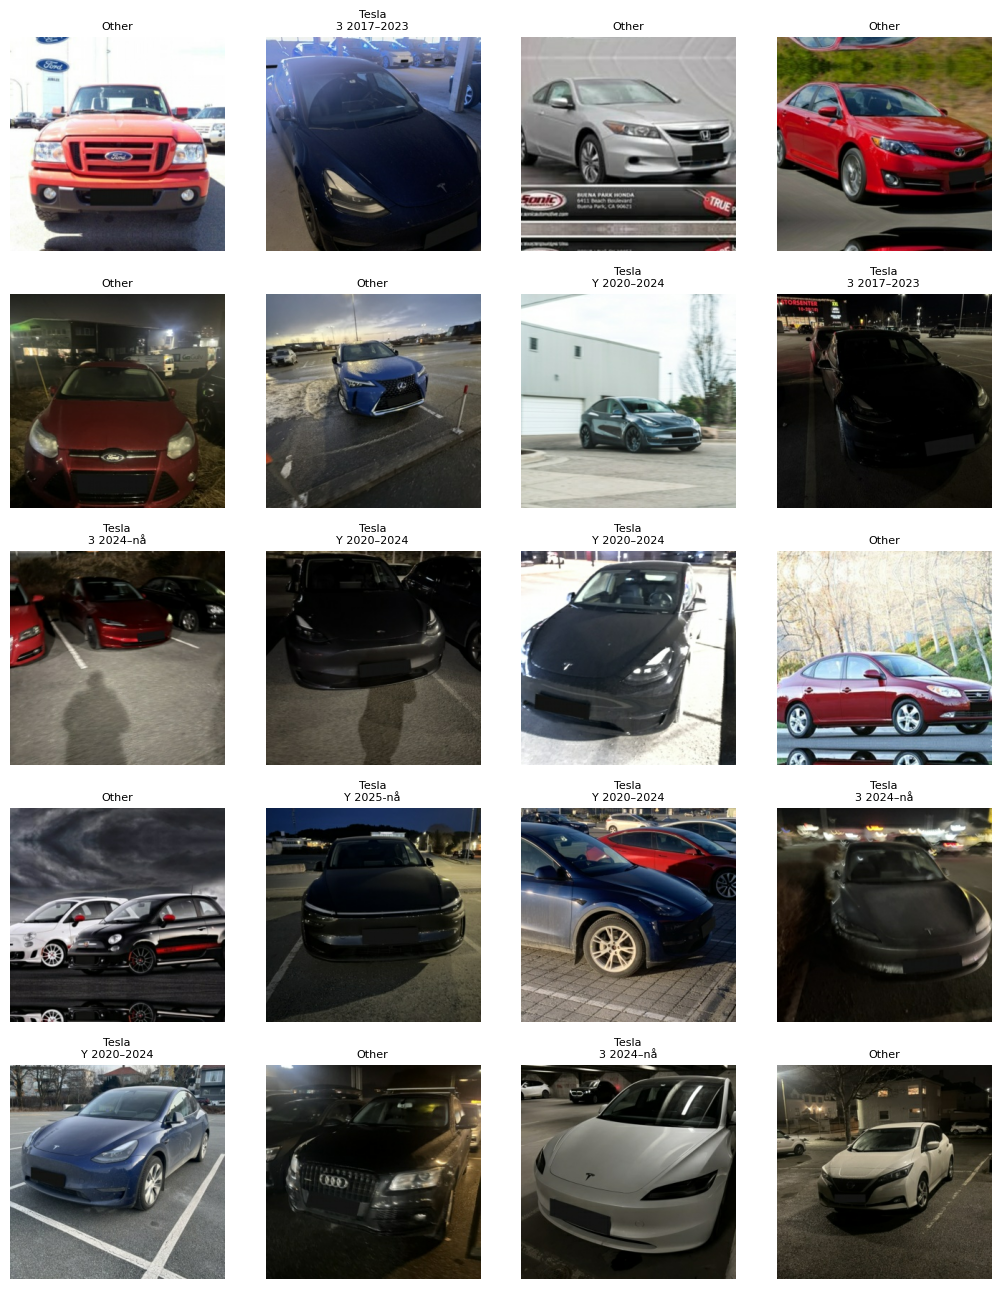

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def show_first_images(ds, n=20, rows=5, cols=4, figsize_scale=2.6, show_titles=True):
    ds = ds.unbatch()
    plt.figure(figsize=(cols*figsize_scale, rows*figsize_scale))

    # Hvis du har disse fra før i notebooken:
    # lvl1_map = {"Other": 0, "Tesla": 1}
    # lvl2_classes = [...]
    inv_lvl1 = {v: k for k, v in lvl1_map.items()}  # 0->Other, 1->Tesla

    for i, elem in enumerate(ds.take(n)):
        # elem kan være (img, y) eller (img, y, sw)
        if isinstance(elem, tuple) and len(elem) == 3:
            img, y, sw = elem
        elif isinstance(elem, tuple) and len(elem) == 2:
            img, y = elem
            sw = None
        else:
            img = elem
            y = None
            sw = None
        # img = img /255.0
        ax = plt.subplot(rows, cols, i + 1)

        im = img.numpy()
        if im.dtype != np.uint8:
            im = np.clip(im, 0.0, 1.0) 
            im = (im * 255).astype(np.uint8)
        ax.imshow(im)
        ax.axis("off")

        if show_titles and isinstance(y, dict):
            y1 = int(y["lvl1"].numpy())
            title = inv_lvl1.get(y1, str(y1))

            # lvl2 kun meningsfull for Tesla (og maskeres for Other via sw["lvl2"]=0)
            if y1 == 1:  # Tesla
                y2 = int(y["lvl2"].numpy())
                lvl2_name = lvl2_classes[y2] if 0 <= y2 < len(lvl2_classes) else str(y2)
                title = f"{title}\n{lvl2_name}"

            ax.set_title(title, fontsize=8)

    plt.tight_layout()
    plt.show()

show_first_images(train_ds, n=20, rows=5, cols=4)

## Modell og logging

De neste blokkene setter opp eksperimentlogging og definerer selve baseline-modellen som skal trenes.

### AIM-logging

Oppretter et unikt eksperimentnavn og konfigurerer `AimCallback` slik at treningskurver og metrikkserier logges til prosjektets `.aim`-repo. Dette brukes senere til å inspisere `loss` og `accuracy` over epoker i AIM.

In [11]:
from aim.tensorflow import AimCallback
import datetime

RUN_ID = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
EXPERIMENT_NAME = f"baseline_hcnn_{RUN_ID}"

aim_callback = AimCallback(
    repo=str(PROJECT_ROOT),                 # -> legger .aim i prosjektroten
    experiment=EXPERIMENT_NAME,
    log_system_params=False,                
)

print("Aim repo:", PROJECT_ROOT / ".aim")
print("Aim experiment:", EXPERIMENT_NAME)

Aim repo: /media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/.aim
Aim experiment: baseline_hcnn_20260329-114247


### Bygg baseline-modellen

Oppretter modellen via `build_model()` og skriver ut et sammendrag av arkitekturen. Fordi modellen er pakket inn i en funksjon, kan samme arkitektur bygges opp igjen senere når lagrede checkpoints skal evalueres og beste epoch skal velges.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = (300, 300)   # same as in your baseline <ref: index=2875893 firstWord=40 lastWord=60/>
num_lvl2 = 7            # change if needed

def build_model(
    img_size=IMG_SIZE,
    num_lvl2=num_lvl2,
    lr=1e-4,
    number_of_trainable_layers = 0
) -> keras.Model:
    inputs = keras.Input(shape=(*img_size, 3), name="image")

    # Pretrained EfficientNetV2S backbone
    backbone = keras.applications.EfficientNetV2S(
        include_top=False,
        input_tensor=inputs,
        pooling="avg",          # gives a flat feature vector
    )

    # 1) Freeze all backbone layers
    for l in backbone.layers:
        l.trainable = False

    # 2) Unfreeze the last number_of_trainable_layers
    for l in backbone.layers[-number_of_trainable_layers:]:
        l.trainable = True


    x = backbone.output
    
    x = layers.Dense(256, activation="relu", name="head_dense_256")(x)
    x = layers.Dropout(0.25)(x)
    
    out_lvl1 = layers.Dense(1, activation="sigmoid", name="lvl1")(x)
    out_lvl2 = layers.Dense(num_lvl2, activation="softmax", name="lvl2")(x)

    model = keras.Model(
        inputs=inputs,
        outputs={"lvl1": out_lvl1, "lvl2": out_lvl2},
        name="efficientnetv2s_hierarchical",
    )

    opt = keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=opt,
        loss={
            "lvl1": keras.losses.BinaryCrossentropy(),
            "lvl2": keras.losses.SparseCategoricalCrossentropy(),
        },
        metrics={
            "lvl1": [keras.metrics.BinaryAccuracy(name="acc")],
        },
        weighted_metrics={
            "lvl2": [keras.metrics.SparseCategoricalAccuracy(name="acc")],
        },
    )
    return model

model = build_model(number_of_trainable_layers=30)




## Kompilering og trening

Modellen kompileres inne i `build_model()`-funksjonen, og den påfølgende treningsblokken bruker dette oppsettet sammen med checkpoint-lagring per epoch. Treningen gjennomføres uten early stopping; i stedet velges beste epoch eksplisitt senere på valideringssettet.

### Modellarkitektur og kompilering

Denne blokken bygger den hierarkiske baseline-modellen i én gjenbrukbar funksjon. Arkitekturen består av en **felles, pretrent backbone** etterfulgt av egne klassifiseringshoder for hvert nivå:

- `lvl1`: binær klassifisering (`Tesla` vs `Other`) med sigmoid-aktivisering
- `lvl2`: flerklasseklassifisering av Tesla-underklasser med softmax-aktivisering

Backbonen lastes med pretrente vekter og kan eventuelt fryses helt eller delvis i starten av treningen, mens de nye klassifiseringshodene initialiseres på nytt. Funksjonen kompilerer også modellen med `Adam(1e-4)`, `binary_crossentropy` for nivå 1 og `sparse_categorical_crossentropy` for nivå 2. Accuracy logges separat per nivå.


### Trening med checkpoint per epoch

Trener modellen i et fast antall epoker og lagrer vekter for **hver** epoch under `checkpoints/<RUN_TAG>/`. AIM brukes som treningslogger, og den siste modellen evalueres kort på valideringssettet etter `fit()`. Denne evalueringen gjelder fortsatt siste epoch, ikke nødvendigvis beste epoch.


In [13]:
import os
os.environ['XLA_FLAGS'] = '--xla_disabled_backends=cpu,gpu'

# 10) Train
EPOCHS = 50
from pathlib import Path

RUN_TAG = "baseline"
ckpt_dir = Path("checkpoints") / RUN_TAG
ckpt_dir.mkdir(parents=True, exist_ok=True)

checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=str(ckpt_dir / "epoch_{epoch:02d}.weights.h5"),
    save_weights_only=True,
    save_best_only=False,   # vi vil kunne evaluere alle epoker i etterkant
    verbose=0
)

callbacks = [
    aim_callback,
    checkpoint_callback,
    # evt. EarlyStopping(...)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Eval (val; lvl2 maskert via sample_weight) – siste epoch, ikke beste:")
print(model.evaluate(val_ds, return_dict=True))

# FINAL Eval på test skal ikke kjøres her.
# Den skal først kjøres etter at beste epoch er valgt på valideringssettet.

Epoch 1/50


I0000 00:00:1774777377.062517   72408 service.cc:148] XLA service 0x7e3fec001f90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774777377.062543   72408 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
I0000 00:00:1774777377.071669   72408 cuda_dnn.cc:529] Loaded cuDNN version 92000
I0000 00:00:1774777377.109846   72408 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2026-03-29 11:43:06.471809: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


2026-03-29 11:43:11.912177: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_24361_0', 112 bytes spill stores, 144 bytes spill loads



2026-03-29 11:43:12.222623: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_24361', 224 bytes spill stores, 224 bytes spill loads

2026-03-29 11:43:12.343858: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_24361', 16 bytes spill stores, 16 bytes spill loads



...


21/26 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.2783 - lvl1_acc: 0.9869 - lvl1_loss: 0.0234 - lvl2_acc: 0.8250 - lvl2_loss: 0.2549


23/26 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.2753 - lvl1_acc: 0.9872 - lvl1_loss: 0.0233 - lvl2_acc: 0.8284 - lvl2_loss: 0.2520


25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.2719 - lvl1_acc: 0.9875 - lvl1_loss: 0.0231 - lvl2_acc: 0.8320 - lvl2_loss: 0.2488


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.2291 - lvl1_acc: 0.9913 - lvl1_loss: 0.0199 - lvl2_acc: 0.8743 - lvl2_loss: 0.2024


{'loss': 0.22911542654037476, 'lvl1_acc': 0.9913259148597717, 'lvl1_loss': 0.019892266020178795, 'lvl2_acc': 0.8742690086364746, 'lvl2_loss': 0.20244097709655762}


## Valideringsbasert epoch-valg og sluttevaluering

Etter trening settes hvilken datasplitt som skal brukes til modellvalg og evaluering. Videre defineres hjelpefunksjoner for nivå 1 og nivå 2, før alle lagrede checkpoints sammenlignes på valideringssettet for å velge én beste epoch. Til slutt kjøres og lagres de endelige nivå 1- og nivå 2-evalueringene for den valgte modellen.

### Velg evalueringssplit

Setter hvilken split som skal brukes i den videre evalueringen. Under modellutvikling brukes normalt `val`, mens samme blokker senere kan kjøres på `test` for endelig rapportering.

In [14]:
EVAL_SPLIT = "val"   # Bruk "val" for epoch-valg og modellutvikling. Bytt til "test" kun for endelig evaluering.
RUN_TAG = "baseline" # Endre per modellvariant hvis du vil lagre separate resultater.

eval_df = {"train": train_df, "val": val_df, "test": test_df}[EVAL_SPLIT].copy()
print("Evaluerer split:", EVAL_SPLIT, "n=", len(eval_df))

Evaluerer split: val n= 807


### Hjelpefunksjoner for nivå 1-evaluering

Definerer funksjoner for prediksjon og evaluering av `lvl1`. Blokken beregner metrikkene både for **Total** og per lyskategori, og returnerer også 2×2-forvirringsmatriser som senere brukes i visualisering og lagring.

In [15]:

from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score
)

def make_x_dataset(df):
    ds = make_dataset(df, training=False)   # deterministisk preprocess
    return ds.map(lambda x, y, sw: x)       # -> x

def predict_heads(model, df):
    x_ds = make_x_dataset(df)
    preds = model.predict(x_ds, verbose=0)
    p1 = preds["lvl1"].reshape(-1)          # sigmoid
    p2 = preds["lvl2"]                      # softmax
    return p1, p2

def plot_cm_2x2(cm, title, save_path=None, ax=None):
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.6, 3.0))
        created_fig = True

    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Other", "Tesla"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Other", "Tesla"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_xlabel("Pred")
    ax.set_ylabel("True")

    if created_fig and save_path:
        plt.tight_layout()
        plt.savefig(save_path, dpi=160)
        plt.show()

def _lvl1_metrics_row(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN FP],[FN TP]]
    tn, fp, fn, tp = cm.ravel()

    tpr = tp / (tp + fn) if (tp + fn) else np.nan
    tnr = tn / (tn + fp) if (tn + fp) else np.nan

    row = {
        "lighting": name,
        "n_total": int(len(y_true)),
        "n_other": int((y_true == 0).sum()),
        "n_tesla": int((y_true == 1).sum()),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "TPR": tpr,
        "TNR": tnr,
        "lvl1_bal_acc": (tpr + tnr) / 2 if np.isfinite(tpr) and np.isfinite(tnr) else np.nan,
        "lvl1_acc": accuracy_score(y_true, y_pred),
        "lvl1_f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "lvl1_maj_acc": max(int((y_true == 0).sum()), int((y_true == 1).sum())) / len(y_true),
    }
    return row, cm

def eval_lvl1_by_lighting(model, df, lighting_col="lighting", threshold=0.5, lighting_order=("Light", "Medium", "Dark")):
    rows = []
    cms = {}

    p1_all, _ = predict_heads(model, df)
    y_true_all = df["y_lvl1"].to_numpy().astype(int)
    y_pred_all = (p1_all >= threshold).astype(int)

    total_row, total_cm = _lvl1_metrics_row("Total", y_true_all, y_pred_all)
    rows.append(total_row)
    cms["Total"] = total_cm

    for light in lighting_order:
        mask = (df[lighting_col].to_numpy() == light)
        if not mask.any():
            continue

        y_true = y_true_all[mask]
        y_pred = y_pred_all[mask]

        row, cm = _lvl1_metrics_row(light, y_true, y_pred)
        rows.append(row)
        cms[light] = cm

    return pd.DataFrame(rows), cms

### Hjelpefunksjoner for nivå 2-evaluering

Definerer tilsvarende evalueringslogikk for `lvl2`, men kun på Tesla-rader. Her beregnes totalmetrikker, metrikk per lyskategori, klassevise precision/recall/F1-verdier og normaliserte forvirringsmatriser for videre analyse.

In [16]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    f1_score, precision_recall_fscore_support
)

def plot_cm_norm(cm_norm, labels, title, save_path=None, max_classes=30):
    plt.figure(figsize=(7.0, 6.0))
    plt.imshow(cm_norm, interpolation="nearest")
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=160)
    plt.show()

def _lvl2_metrics_row(name, y_true, y_pred):
    counts = np.bincount(y_true, minlength=num_lvl2)
    maj_acc = counts.max() / len(y_true) if len(y_true) else np.nan

    row = {
        "lighting": name,
        "n_tesla": int(len(y_true)),
        "lvl2_acc": accuracy_score(y_true, y_pred),
        "lvl2_bal_acc": balanced_accuracy_score(y_true, y_pred),
        "lvl2_f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "lvl2_maj_acc": maj_acc,
    }

    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_lvl2)))
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = cm / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)

    return row, cm, cm_norm

def eval_lvl2(model, df, lighting_col="lighting", lighting_order=("Light", "Medium", "Dark"), topn=8):
    tesla_df = df[df["y_lvl1"].astype(int) == 1].copy()
    if tesla_df.empty:
        raise ValueError("Ingen Tesla-rader i eval_df – kan ikke evaluere lvl2.")

    preds = model.predict(make_x_dataset(tesla_df), verbose=0)
    p2 = preds["lvl2"]

    y_true = tesla_df["y_lvl2"].to_numpy().astype(int)
    y_pred = np.argmax(p2, axis=1).astype(int)

    total_row, cm, cm_norm = _lvl2_metrics_row("Total", y_true, y_pred)
    df_overall = pd.DataFrame([{
        "n_tesla": total_row["n_tesla"],
        "lvl2_acc": total_row["lvl2_acc"],
        "lvl2_bal_acc": total_row["lvl2_bal_acc"],
        "lvl2_f1_macro": total_row["lvl2_f1_macro"],
        "lvl2_maj_acc": total_row["lvl2_maj_acc"],
    }])

    rows = [total_row]
    cm_norm_by_light = {"Total": cm_norm}

    for light in lighting_order:
        mask = (tesla_df[lighting_col].to_numpy() == light)
        if mask.sum() == 0:
            continue

        y_t = y_true[mask]
        y_p = y_pred[mask]

        row, _, cm_l_norm = _lvl2_metrics_row(light, y_t, y_p)
        rows.append(row)
        cm_norm_by_light[light] = cm_l_norm

    df_by_light = pd.DataFrame(rows)

    support_tbl = (
        tesla_df.groupby(["lvl2", lighting_col]).size()
        .unstack(lighting_col, fill_value=0)
        .reindex(index=lvl2_classes, fill_value=0)
    )
    support_tbl["Total"] = support_tbl.sum(axis=1)
    support_tbl.loc["Total"] = support_tbl.sum(axis=0)

    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(num_lvl2)), zero_division=0
    )
    df_per_class = pd.DataFrame({
        "class_id": range(num_lvl2),
        "class": lvl2_classes,
        "support": sup,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }).sort_values(["recall", "support"], ascending=[True, True])

    confusions = []
    for i in range(num_lvl2):
        row = cm_norm[i].copy()
        row[i] = 0.0
        j = int(np.argmax(row))
        if row[j] > 0:
            confusions.append((lvl2_classes[i], lvl2_classes[j], float(row[j]), int(cm[i].sum())))

    df_confusions = (
        pd.DataFrame(confusions, columns=["true", "pred", "rate", "support_true"])
        .sort_values(["rate", "support_true"], ascending=[False, False])
        .head(5)
    )

    return df_overall, df_by_light, support_tbl, df_per_class, cm_norm, df_confusions, cm_norm_by_light

### Velg beste epoch fra valideringssettet

Laster inn alle lagrede checkpoints, evaluerer dem på valgt split og rangerer epokene etter en samlet score:

- `0.5 * lvl1_total_f1_macro`
- `0.5 * lvl2_total_f1_macro`

Den beste epoken lastes deretter inn på nytt i `model`, slik at de neste evalueringsblokkene bruker én konsistent modell.

In [17]:
import re
# Finn lagrede checkpoints fra treningen
ckpt_dir = Path("checkpoints") / RUN_TAG
ckpt_files = sorted(ckpt_dir.glob("epoch_*.weights.h5"))

if not ckpt_files:
    raise FileNotFoundError(f"Fant ingen checkpoints i {ckpt_dir}")

rows = []
tmp_model = build_model()
for ckpt in ckpt_files:
    # Bygg samme arkitektur på nytt
    tmp_model.load_weights(str(ckpt))

    # Eval lvl1 -> hent Total F1
    df_lvl1_tmp, _ = eval_lvl1_by_lighting(tmp_model, eval_df, threshold=0.5)
    lvl1_total_f1 = float(
        df_lvl1_tmp.loc[df_lvl1_tmp["lighting"] == "Total", "lvl1_f1_macro"].iloc[0]
    )

    # Eval lvl2 -> hent Total F1
    _, df_lvl2_tmp, _, _, _, _, _ = eval_lvl2(tmp_model, eval_df)
    lvl2_total_f1 = float(
        df_lvl2_tmp.loc[df_lvl2_tmp["lighting"] == "Total", "lvl2_f1_macro"].iloc[0]
    )

    # 50/50 samlet score
    total_score = 0.5 * lvl1_total_f1 + 0.5 * lvl2_total_f1

    epoch_num = int(re.search(r"epoch_(\d+)", ckpt.name).group(1))

    rows.append({
        "epoch": epoch_num,
        "lvl1_total_f1_macro": lvl1_total_f1,
        "lvl2_total_f1_macro": lvl2_total_f1,
        "score_50_50": total_score,
        "checkpoint": str(ckpt),
    })

epoch_scores = pd.DataFrame(rows).sort_values("epoch").reset_index(drop=True)
display(epoch_scores)

best_row = epoch_scores.sort_values("score_50_50", ascending=False).iloc[0]
best_epoch = int(best_row["epoch"])
best_ckpt = best_row["checkpoint"]

print(f"Best epoch: {best_epoch}")
print(f"Best checkpoint: {best_ckpt}")
print(f"Lvl1 Total F1: {best_row['lvl1_total_f1_macro']:.4f}")
print(f"Lvl2 Total F1: {best_row['lvl2_total_f1_macro']:.4f}")
print(f"50/50 score:   {best_row['score_50_50']:.4f}")

# Last inn beste epoch i modellen som skal brukes videre
model = build_model()
model.load_weights(best_ckpt)

print(f"Modellen er nå lastet med beste epoch = {best_epoch}")

/media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 64 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


/media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 64 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


/media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 64 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


/media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 64 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


/media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 64 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


...

/media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 64 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


,epoch,lvl1_total_f1_macro,lvl2_total_f1_macro,score_50_50,checkpoint
0,1,0.934497,0.352543,0.643520,checkpoints/baseline/epoch_01.weights.h5
1,2,0.960937,0.595702,0.778320,checkpoints/baseline/epoch_02.weights.h5
2,3,0.974666,0.711125,0.842895,checkpoints/baseline/epoch_03.weights.h5
3,4,0.982279,0.806759,0.894519,checkpoints/baseline/epoch_04.weights.h5
4,5,0.984776,0.858707,0.921742,checkpoints/baseline/epoch_05.weights.h5
5,6,0.983563,0.849980,0.916772,checkpoints/baseline/epoch_06.weights.h5
6,7,0.984811,0.832014,0.908412,checkpoints/baseline/epoch_07.weights.h5
7,8,0.988587,0.880210,0.934398,checkpoints/baseline/epoch_08.weights.h5
8,9,0.989851,0.857535,0.923693,checkpoints/baseline/epoch_09.weights.h5
9,10,0.988612,0.864687,0.926650,checkpoints/baseline/epoch_10.weights.h5


Best epoch: 45
Best checkpoint: checkpoints/baseline/epoch_45.weights.h5
Lvl1 Total F1: 0.9924
Lvl2 Total F1: 0.9058
50/50 score:   0.9491


Modellen er nå lastet med beste epoch = 45


/media/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 64 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### Kjør og lagre nivå 1-resultater

Kjører endelig `lvl1`-evaluering for den modellen som nå er lastet inn, lagrer metrikk-tabellen til disk og produserer forvirringsmatriser for `Light`, `Medium` og `Dark`.

,lighting,n_total,n_other,n_tesla,TN,FP,FN,TP,TPR,TNR,lvl1_bal_acc,lvl1_acc,lvl1_f1_macro,lvl1_maj_acc
0,Total,807,465,342,460,5,1,341,0.997076,0.989247,0.993162,0.992565,0.992400,0.576208
1,Light,442,282,160,279,3,1,159,0.993750,0.989362,0.991556,0.990950,0.990230,0.638009
2,Medium,185,93,92,93,0,0,92,1.000000,1.000000,1.000000,1.000000,1.000000,0.502703
3,Dark,180,90,90,88,2,0,90,1.000000,0.977778,0.988889,0.988889,0.988888,0.500000


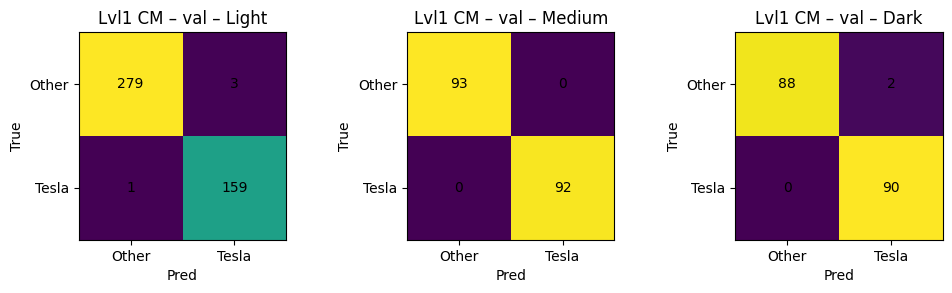

In [18]:
out_dir = Path("results") / RUN_TAG / EVAL_SPLIT / "lvl1"
out_dir.mkdir(parents=True, exist_ok=True)

df_lvl1, cm_by_light = eval_lvl1_by_lighting(model, eval_df, threshold=0.5)
df_lvl1.to_csv(out_dir / "lvl1_metrics_by_lighting.csv", index=False, encoding="utf-8")
display(df_lvl1)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.0))

for ax, light in zip(axes, ("Light", "Medium", "Dark")):
    if light in cm_by_light:
        plot_cm_2x2(cm_by_light[light], f"Lvl1 CM – {EVAL_SPLIT} – {light}", ax=ax)

fig.tight_layout()
fig.savefig(out_dir / "cm_lvl1_all.png", dpi=160)
plt.show()

### Kjør og lagre nivå 2-resultater

Kjører tilsvarende sluttevaluering for `lvl2`, lagrer metrikk per lyskategori, klassevise PR/F1-resultater og de vanligste forvekslingene, og visualiserer normaliserte forvirringsmatriser for Tesla-underklassene.

,lighting,n_tesla,lvl2_acc,lvl2_bal_acc,lvl2_f1_macro,lvl2_maj_acc
0,Total,342,0.918129,0.894229,0.905779,0.374269
1,Light,160,0.862500,0.857697,0.866558,0.362500
2,Medium,92,0.956522,0.883333,0.891629,0.380435
3,Dark,90,0.977778,0.970068,0.977475,0.388889


,class_id,class,support,precision,recall,f1
3,3,S 2016–nå,20,0.833333,0.750000,0.789474
0,0,3 2017–2023,51,0.851064,0.784314,0.816327
2,2,S 2012–2015,16,1.000000,0.875000,0.933333
1,1,3 2024–nå,37,0.972222,0.945946,0.958904
4,4,X,41,0.886364,0.951220,0.917647
5,5,Y 2020–2024,128,0.917293,0.953125,0.934866
6,6,Y 2025-nå,49,0.980000,1.000000,0.989899


,true,pred,rate,support_true
0,3 2017–2023,Y 2020–2024,0.176471,51
3,S 2016–nå,X,0.100000,20
2,S 2012–2015,3 2024–nå,0.062500,16
1,3 2024–nå,3 2017–2023,0.054054,37
4,X,3 2017–2023,0.024390,41


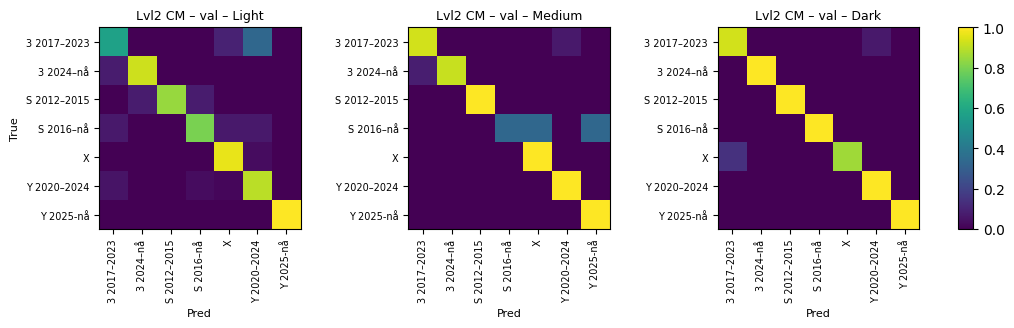

In [19]:

out_dir = Path("results") / RUN_TAG / EVAL_SPLIT / "lvl2"
out_dir.mkdir(parents=True, exist_ok=True)

df_lvl2_overall, df_lvl2_by_light, support_tbl, df_lvl2_per_class, cm_norm, df_confusions, cm_norm_by_light = eval_lvl2(model, eval_df)


df_lvl2_by_light.to_csv(out_dir / "lvl2_metrics_by_lighting.csv", index=False, encoding="utf-8")
df_lvl2_per_class.to_csv(out_dir / "lvl2_per_class_pr.csv", index=False, encoding="utf-8")
df_confusions.to_csv(out_dir / "lvl2_top_confusions.csv", index=False, encoding="utf-8")


display(df_lvl2_by_light)
display(df_lvl2_per_class.head(10))
display(df_confusions)

fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.6))

for k, (ax, light) in enumerate(zip(axes, ("Light", "Medium", "Dark"))):
    if light not in cm_norm_by_light:
        ax.axis("off")
        continue

    im = ax.imshow(cm_norm_by_light[light], interpolation="nearest", vmin=0, vmax=1)
    ax.set_title(f"Lvl2 CM – {EVAL_SPLIT} – {light}", fontsize=9)

    ax.set_xticks(range(num_lvl2))
    ax.set_xticklabels(lvl2_classes, rotation=90, fontsize=7)
    ax.set_yticks(range(num_lvl2))
    ax.set_yticklabels(lvl2_classes, fontsize=7)

    ax.set_xlabel("Pred", fontsize=8)
    ax.set_ylabel("True" if k == 0 else "", fontsize=8)

fig.subplots_adjust(left=0.06, right=0.90, top=0.86, bottom=0.30, wspace=0.30)

cax = fig.add_axes([0.92, 0.30, 0.015, 0.56])
fig.colorbar(im, cax=cax)

fig.savefig(out_dir / "cm_lvl2_norm_by_lighting.png", dpi=160)
plt.show()